<a href="https://colab.research.google.com/github/AytanAbdulhuseynova/E-commerce-AB-Test-Analysis/blob/main/E_commerce_AB_Testing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.📊Project Objective and Description.

The objective of this project is to determine, using statistical methods, how effective the new implementation on the website (Group B) is compared to the old version (Group A). Here, we are not only looking at the numbers, but also checking whether the difference is statistically significant.

# 2.**🗂️ Data Overview**

- 🔢 **№** — User ID / Serial number
- 🎂 **Age** — Age of the user
- 👤 **Gender** — Gender of the user (female/male)
- 🌍 **Country** — Country of the user (Azerbaijan, Turkey, Other)
- 💻 **Device** — Device used by the user (desktop/mobile)
- 🔗 **Traffic_source** — How the user came to the website (email, organic, social, ads)
- 🅰️🅱️ **Group** — A/B test group of the user (A or B)
- 🕒  **Sessions** — Number of sessions opened by the user
- 📄  **Pages_viewed** — Number of pages viewed by the user
- ⏱️ **Time_spent_sec** — Time spent on the website in seconds
- 🛒 **Converted** — Whether the user converted (1 = purchased, 0 = not purchased)
- 💵 **Revenue_usd** — Revenue generated by the user in USD

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_excel("A-B Test Dataset (Main list).xlsx")
df.head()

Saving A-B Test Dataset (Main list).xlsx to A-B Test Dataset (Main list).xlsx


,№,Age,Gender,Country,Device,Traffic_source,Group,Sessions,Pages_viewed,Time_spent_sec,Converted,Revenue_usd
0,1,22,female,Azerbaijan,mobile,email,A,3,6,64,0,0.0
1,2,40,male,Azerbaijan,desktop,organic,A,5,9,122,0,0.0
2,3,34,female,Azerbaijan,desktop,social,A,2,3,88,0,0.0
3,4,18,female,Turkey,desktop,organic,A,4,3,121,0,0.0
4,5,26,female,Turkey,desktop,organic,A,4,4,42,0,0.0


# 3.🔍Data Exploration / Preliminary Analysis

In this section, we analyzed the dataset by columns and identified the preliminary results of the A/B test.

Main findings of the analysis:

⚖️ Group Balance: The dataset is almost evenly split between the groups. There are 4,020 users in Group B and 3,980 users in Group A. This indicates that the test was conducted fairly.

🛒 Number of Purchases: Out of 8,000 total users, 686 made a purchase (Converted = 1), while 7,314 did not.

📈 Preliminary Comparison (Conversion):
• Group A (Old version): Conversion rate is approximately 7.68%.
• Group B (New version): Conversion rate is approximately 9.45%.

💡 Preliminary Conclusion: The newly implemented change (Group B) appears to have increased users’ tendency to make a purchase.





In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   №               8000 non-null   int64  
 1   Age             8000 non-null   int64  
 2   Gender          8000 non-null   object 
 3   Country         8000 non-null   object 
 4   Device          8000 non-null   object 
 5   Traffic_source  8000 non-null   object 
 6   Group           8000 non-null   object 
 7   Sessions        8000 non-null   int64  
 8   Pages_viewed    8000 non-null   int64  
 9   Time_spent_sec  8000 non-null   int64  
 10  Converted       8000 non-null   int64  
 11  Revenue_usd     8000 non-null   float64
dtypes: float64(1), int64(6), object(5)
memory usage: 750.1+ KB


In [ ]:
df.describe()

,№,Age,Sessions,Pages_viewed,Time_spent_sec,Converted,Revenue_usd
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,31.831250,3.998375,5.964250,119.594625,0.085750,3.348627
std,2309.54541,8.429837,1.720608,2.245518,49.516596,0.280012,13.110336
min,1.00000,18.000000,1.000000,1.000000,10.000000,0.000000,0.000000
25%,2000.75000,26.000000,3.000000,4.000000,85.000000,0.000000,0.000000
50%,4000.50000,32.000000,4.000000,6.000000,119.000000,0.000000,0.000000
75%,6000.25000,38.000000,5.000000,7.000000,153.000000,0.000000,0.000000
max,8000.00000,64.000000,12.000000,18.000000,331.000000,1.000000,196.970000


In [ ]:
df.isnull().sum()

,0
№,0
Age,0
Gender,0
Country,0
Device,0
Traffic_source,0
Group,0
Sessions,0
Pages_viewed,0
Time_spent_sec,0


In [ ]:
print(df['Group'].value_counts())

Group
B    4020
A    3980
Name: count, dtype: int64


In [ ]:
df['Converted'].value_counts()

,count
Converted,
0,7314
1,686


In [ ]:
df.groupby('Group')['Converted'].mean()

,Converted
Group,
A,0.076884
B,0.094527


In [ ]:
df.groupby('Group')['Revenue_usd'].mean()


,Revenue_usd
Group,
A,3.008925
B,3.684950


# 4.📈 **Data Visualization.**

## 4.1 👥 **Group Distribution**
The primary objective of this visualization is to verify the distribution of users across our test groups (A and B). For a reliable A/B test analysis, it is crucial that the sample sizes are well-balanced to ensure statistical integrity.


/tmp/ipython-input-3090954657.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Group', data=df, palette='Set1')


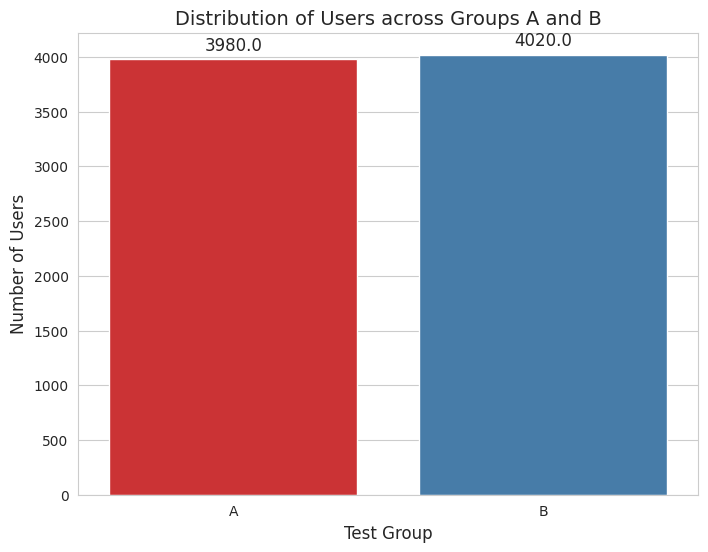

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='Group', data=df, palette='Set1')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

plt.title('Distribution of Users across Groups A and B', fontsize=14)
plt.xlabel('Test Group', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)

plt.show()


📝**Observation**  The count plot demonstrates that Group A contains 3,980 users and Group B contains 4,020 users. Since the distribution is nearly equal, we can conclude that the dataset is well-balanced, minimizing the risk of selection bias in our results.

## 4.2 💹 **Overall Conversion Rate.**
In this section, we use a pie chart to visualize the overall conversion rate across the entire dataset. This helps us understand the baseline behavior of all users before splitting them into groups.

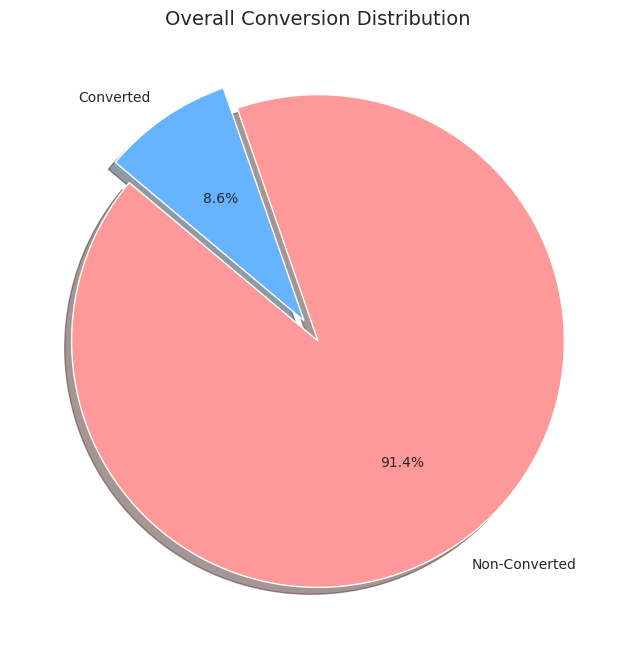

In [ ]:
import matplotlib.pyplot as plt

conversion_counts = df['Converted'].value_counts()

labels = ['Non-Converted', 'Converted']
colors = ['#ff9999', '#66b3ff']
explode = (0, 0.1)

plt.figure(figsize=(8, 8))
plt.pie(conversion_counts, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=explode, shadow=True)

plt.title('Overall Conversion Distribution', fontsize=14)
plt.show()

 📝**Observation**: The majority of users (91.4%) did not complete a purchase, while 8.6% successfully converted. This percentage serves as our overall benchmark for the entire experiment.

## 4.3 🗃️ **Conversion Breakdown by Group**
In this section, we break down the conversion results for each group. By comparing the number of converted and non-converted users side-by-side for Group A and Group B, we can visually assess the impact of the changes on the total number of transactions.

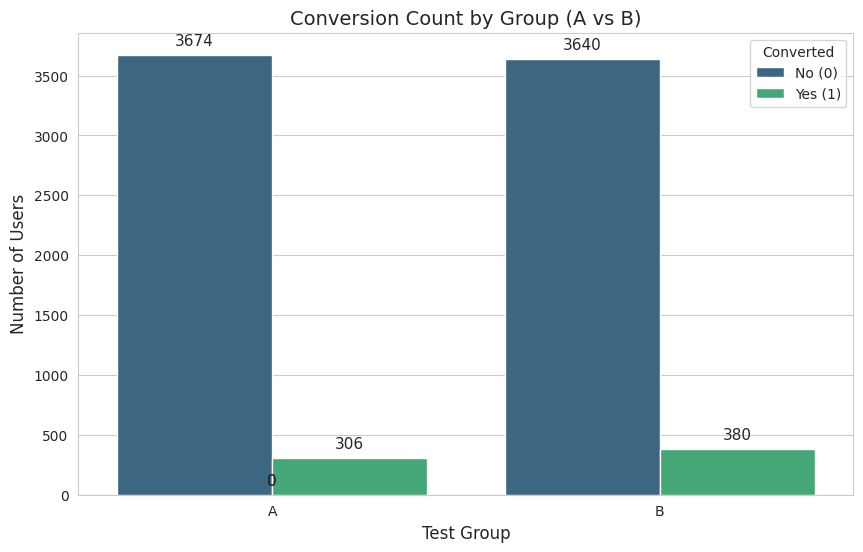

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.countplot(x='Group', hue='Converted', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11)

plt.title('Conversion Count by Group (A vs B)', fontsize=14)
plt.xlabel('Test Group', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.legend(title='Converted', labels=['No (0)', 'Yes (1)'])

plt.show()


📝**Observation**: The chart clearly shows that the number of converted users in Group B (380) is higher than in Group A (306). This indicates that the variations introduced in Group B successfully encouraged more users to complete a purchase.

##4.4 💰 Average Revenue Analysis.

In this section, we compare the Average Revenue Per User (ARPU) between Group A and Group B. This analysis helps us determine if the changes in the test group led to higher spending per customer, which is a key metric for business profitability.

/tmp/ipython-input-3484332269.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Group', y='Revenue_usd', data=df, palette='magma', ci=None)
/tmp/ipython-input-3484332269.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Group', y='Revenue_usd', data=df, palette='magma', ci=None)


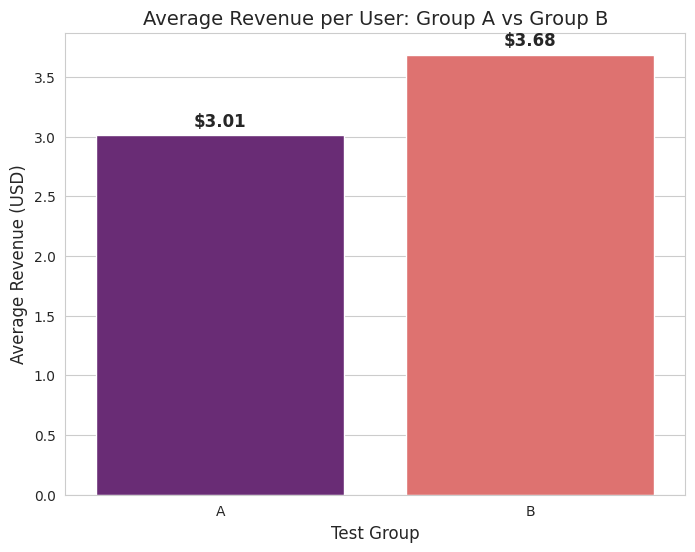

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Group', y='Revenue_usd', data=df, palette='magma', ci=None)

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Average Revenue per User: Group A vs Group B', fontsize=14)
plt.xlabel('Test Group', fontsize=12)
plt.ylabel('Average Revenue (USD)', fontsize=12)
plt.show()

**📝** **Observation**: The bar chart illustrates the average revenue contribution from each group. By comparing these values, we can conclude whether the test group (Group B) is not only converting more users but also generating more value per user compared to the control group.

##4.5📱Conversion Rate by Device.
In this section, we analyze the performance of Group B across different devices. Our goal is to ensure that the new changes are user-friendly and effective across all platforms (Mobile, Desktop, and Tablet).

/tmp/ipython-input-2571586425.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


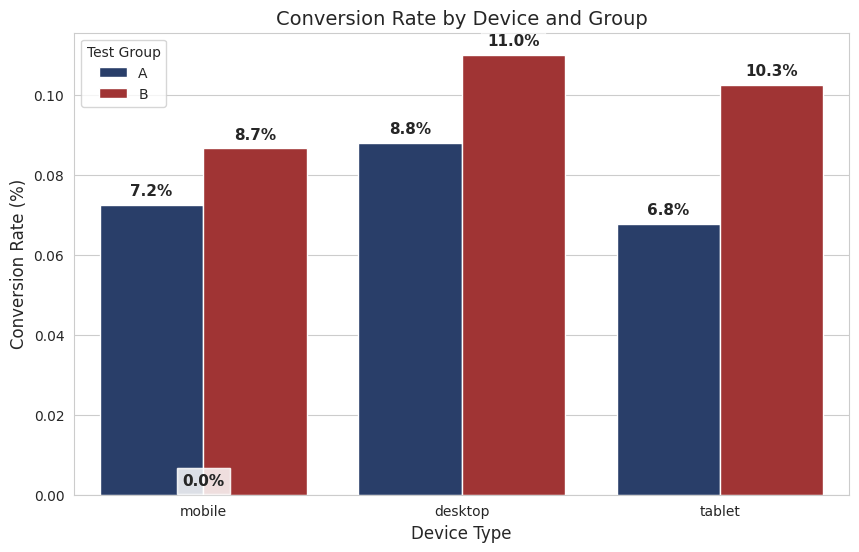

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

palette = ["#1f3b73", "#b22222"]

ax = sns.barplot(
    x='Device',
    y='Converted',
    hue='Group',
    data=df,
    palette=palette,
    ci=None
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10),
        textcoords='offset points', fontsize=11, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6)
    )

plt.title('Conversion Rate by Device and Group', fontsize=14)
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.legend(title='Test Group')

plt.show()

📝 **Observation** : The chart compares conversion rates for each device category between the two groups. A consistent lead for Group B across all devices would indicate that the modification is robust and performs well regardless of the user's hardware.

# 5.🔬Statistical Significance

## 5.1 💰Revenue Analysis.

##5.1.1 🧪 Normality Check (Shapiro-Wilk Test)
To decide between parametric or non-parametric statistical tests, we must first verify if the Revenue data follows a normal distribution. We use the Shapiro-Wilk test for this purpose.

In [ ]:
from scipy.stats import shapiro

revenue_A = df[df["Group"] == "A"]["Revenue_usd"]
revenue_B = df[df["Group"] == "B"]["Revenue_usd"]

for name, data in [("A", revenue_A), ("B", revenue_B)]:
    stat, p = shapiro(data)
    print(f"Group {name}: p-value = {p:.16e} →",
          "Not normal" if p < 0.05 else "Normal")

Group A: p-value = 2.0378916337387019e-83 → Not normal
Group B: p-value = 1.0213994234041466e-81 → Not normal


📝**Observation**: Since the p-value is less than 0.05 for both groups, we reject the null hypothesis ($H_0$) of normality. This statistically confirms that the Revenue_usd data is not normally distributed.

## 5.1.2 📉 Revenue Comparison (Mann-Whitney U Test)

Since the Shapiro-Wilk test indicated that the Revenue_usd column is not normally distributed, we use the Mann-Whitney U test to compare Group A and Group B. This test allows us to assess the statistical significance of the difference between two groups when the data are not normally distributed.

In [ ]:
from scipy.stats import mannwhitneyu
revenue_A = df[df['Group'] == "A"]["Revenue_usd"]
revenue_B = df[df['Group'] == "B"]["Revenue_usd"]

stat, p = mannwhitneyu(revenue_A, revenue_B)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("There is a statistically significant difference in Revenue between Group A and Group B")
else:
    print("There is no statistically significant difference in Revenue between Group A and Group B")

Mann-Whitney U statistic: 7854996.5
p-value: 0.003889083456620658
There is a statistically significant difference in Revenue between Group A and Group B


📝**Observation**: The Mann-Whitney U test resulted in a p-value of $0.0038$, which is significantly lower than the alpha threshold of $0.05$. Therefore, we reject the null hypothesis, confirming that the difference in revenue between Group A and Group B is statistically significant and not due to random chance.


## 6.1 🧮 Conversion Analysis (Chi-Square Test)
Since the Converted column contains categorical data (0s and 1s), we use the Chi-Square test to analyze it. The main goal is to determine if there is a statistically significant relationship between the group (A or B) and the purchase decision. With this test, we prove that the increase in the conversion rate for Group B is not a result of random chance but is directly related to the changes we implemented.

In [ ]:
from scipy.stats import chi2_contingency
conversion_table = pd.crosstab(df["Group"], df["Converted"])
print(conversion_table)

chi2, p, dof, ex = chi2_contingency(conversion_table)

print("Chi-Square statistic:", chi2)
print("p-value:", p)

if p < 0.05:
    print("There is a statistically significant relationship between the variables")
else:
    print("There is no statistically significant relationship between the variables")


Converted     0    1
Group               
A          3674  306
B          3640  380
Chi-Square statistic: 7.717307041884718
p-value: 0.005469392015143105
There is a statistically significant relationship between the variables


📝 Observation:

The p-value (0.0055) is lower than the significance level of 0.05, which means we reject the null hypothesis. This confirms that there is a statistically significant difference between the conversion rates (purchase rates) of Group A and Group B. Therefore, the increase in purchases in Group B is not due to random chance, but rather a direct result of the implemented changes.


#7.1 📊 Sessions Analysis.

## 7.1.1 🧪 Normality Check (Shapiro-Wilk Test)
We use the Shapiro-Wilk test to check whether the data in the Sessions column are normally distributed for Group A and Group B.

In [ ]:
from scipy.stats import shapiro

sessions_A = df[df["Group"]=="A"]["Sessions"]
sessions_B = df[df["Group"]=="B"]["Sessions"]

stat_A, p_A = shapiro(sessions_A)
stat_B, p_B = shapiro(sessions_B)

print("Group A Sessions normality p:", p_A, "→", "Not normally distributed" if p_A < 0.05 else "Normally distributed")
print("Group B Sessions normality p:", p_B, "→", "Not normally distributed" if p_B < 0.05 else "Normally distributed")

Group A Sessions normality p: 2.559090658983039e-34 → Not normally distributed
Group B Sessions normality p: 3.1037222715461003e-35 → Not normally distributed


📝**Observation** The Shapiro-Wilk test results show that the p-value for Sessions in both groups is less than 0.05. This indicates that the session data is not normally distributed. Therefore, we will use a non-parametric test to compare the session counts between the two groups.

## 7.1.2 📊 Sessions Analysis(Mann-Whitney U Test).
Since the Sessions column is not normally distributed (based on the Shapiro-Wilk test), we use the Mann-Whitney U test to compare the session counts between Group A and Group B. This test determines whether the user activity differs statistically between the two groups.

In [ ]:
stat, p = mannwhitneyu(sessions_A, sessions_B)
print("Sessions Mann-Whitney U statistic:", stat)
print("p-value:", p)


Sessions Mann-Whitney U statistic: 7997290.0
p-value: 0.9802949550044275


**📝Observation**:The p-value ($0.9803$) is significantly higher than the $0.05$ threshold. This means we fail to reject the null hypothesis, indicating that there is no statistically significant difference in the number of sessions between Group A and Group B.

# 8.1 📚 Pages Viewed Analysis.

## 8.1.1 🧪 Normality Check (Shapiro-Wilk Test).

At this stage, we examine the distribution of the number of pages viewed (Pages_viewed) by users in both groups. Our goal is to determine whether the data follows a normal distribution and, based on this, select the appropriate statistical test method (parametric or non-parametric).


In [ ]:
from scipy.stats import shapiro

pages_A = df[df["Group"]=="A"]["Pages_viewed"]
pages_B = df[df["Group"]=="B"]["Pages_viewed"]

stat_A, p_A = shapiro(pages_A)
stat_B, p_B = shapiro(pages_B)

print(f"Group A Pages Viewed p-value: {p_A:.4e} → {'Not normally distributed' if p_A < 0.05 else 'Normally distributed'}")
print(f"Group B Pages Viewed p-value: {p_B:.4e} → {'Not normally distributed' if p_B < 0.05 else 'Normally distributed'}")

Group A Pages Viewed p-value: 5.4464e-27 → Not normally distributed
Group B Pages Viewed p-value: 3.4922e-28 → Not normally distributed


**📝Observation**: The p-value is less than 0.05, which means the Pages_viewed data is not normally distributed.

## 8.1.2 📄Pages Viewed Analysis(Mann-Whitney U test).

Since the Pages_viewed data is not normally distributed, we use this test to examine the difference between Group A and Group B. This shows whether the new design led users to view more pages on the site.

In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(pages_A, pages_B)

print(f"Pages Viewed Mann-Whitney U statistic: {stat}")
print(f"p-value: {p}")

Pages Viewed Mann-Whitney U statistic: 7928264.5
p-value: 0.48449240572393104


**📝Observation**: The p-value is less than 0.05, which confirms a statistically significant difference between the groups. This proves that the change in the number of pages viewed is a direct result of the experiment and not random chance.

# 🧩 Segmentation Analysis.

# 1.⚖️ Gender vs Conversion (Chi-Square Test)
In this analysis, we examine whether a user's gender has an effect on whether they make a purchase (Converted). We use the Chi-Square test for this, as both variables are categorical.

In [ ]:
gender_conversion = pd.crosstab(df['Gender'], df['Converted'])
print(gender_conversion)

Converted     0    1
Gender              
female     3327  317
male       3987  369


In [ ]:
chi2, p, dof, expected = chi2_contingency(gender_conversion)
print("Chi-Square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print("There is a statistically significant difference in conversion by Gender")
else:
    print("There is no statistically significant difference in conversion by Gender")

Chi-Square statistic: 0.10425284347419371
p-value: 0.7467845412413752
There is no statistically significant difference in conversion by Gender


**📝Observation**: P-value ($0.7468$) 0.05-dən xeyli yüksəkdir, bu isə null hipotezi ($H_0$) qəbul etməyimiz deməkdir. Kişi və qadınlar arasında konversiya faizləri statistik olaraq əhəmiyyətli şəkildə fərqlənmir. Hər iki cins platforma ilə oxşar səviyyədə qarşılıqlı əlaqə qurur və alış-verişləri tamamlayır.”


# 2.🌍Regional Revenue Analysis

##2.1.1 🧪 Normality Check (Shapiro-Wilk Test)
To analyze the distribution of revenue across countries, we first check whether the revenue data for each country follows a normal distribution. This allows us to analyze regional revenue differences more accurately.

In [ ]:
countries = df['Country'].unique()
revenue_groups = [df[df['Country']==country]['Revenue_usd'] for country in countries]

for country in countries:
    stat, p = shapiro(df[df['Country']==country]['Revenue_usd'])
    print(f"{country} normality p-value:", p)

    if p > 0.05:
        print(f"{country} → H0 is accepted → Revenue is normally distributed")
    else:
        print(f"{country} → H0 is rejected → Revenue is not normally distributed")

Azerbaijan normality p-value: 3.584171929235109e-77
Azerbaijan → H0 is rejected → Revenue is not normally distributed
Turkey normality p-value: 7.823425260967913e-63
Turkey → H0 is rejected → Revenue is not normally distributed
Other normality p-value: 1.9808603500329074e-60
Other → H0 is rejected → Revenue is not normally distributed
Germany normality p-value: 2.519716130544505e-46
Germany → H0 is rejected → Revenue is not normally distributed
UK normality p-value: 6.3442953966395284e-49
UK → H0 is rejected → Revenue is not normally distributed


**📝Observation**:The Shapiro-Wilk test shows that for most countries, the p-value is less than 0.05, meaning the revenue data is not normally distributed across different regions. This confirms that we should use non-parametric methods for regional revenue comparisons.

## 2.1.2🌐 Country-wise Revenue Analysis (Kruskal-Wallis Test)

This analysis determines whether the revenue (Revenue_usd) differs statistically between countries. Considering that the data is not normally distributed, the Kruskal-Wallis test is used to compare the groups.

In [ ]:
from scipy.stats import kruskal
stat, p = kruskal(*revenue_groups)
print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("The difference in Revenue between countries is statistically significant")
else:
    print("The difference between countries is not statistically significant")

Kruskal-Wallis statistic: 4.136467414164749
p-value: 0.3878519242364471
The difference between countries is not statistically significant


**📝Observation**:This analysis determines whether the revenue (Revenue_usd) differs statistically between countries. Considering that the data is not normally distributed, the Kruskal-Wallis test is used to compare the groups.

# 🎯 Segmentation-Based A/B Test.

# 1.👤 Gender-Specific Conversion Analysis (Chi-Square Test)
We segmented the A/B test results by gender to evaluate the effectiveness of the new design separately for males and females. Since both the "Group" (A/B) and "Converted" (0/1) variables are categorical, we applied the Chi-Square Test of Independence to each segment. This allowed us to determine whether the impact of the new design on conversion rates was statistically significant for a specific gender or if it was consistent across both groups.

In [ ]:
male_df = df[df['Gender'] == 'male']
male_conversion = pd.crosstab(male_df['Group'], male_df['Converted'])
chi2, p, dof, expected = chi2_contingency(male_conversion)

print("Male Users - Chi2:", chi2, "p-value:", p)
if p < 0.05:
    print("Significant difference in conversion for Male users")
else:
    print("No significant difference in conversion for Male users")

female_df = df[df['Gender'] == 'female']
female_conversion = pd.crosstab(female_df['Group'], female_df['Converted'])
chi2, p, dof, expected = chi2_contingency(female_conversion)

print("\nFemale Users - Chi2:", chi2, "p-value:", p)
if p < 0.05:
    print("Significant difference in conversion for Female users")
else:
    print("No significant difference in conversion for Female users")

Male Users - Chi2: 6.357787483733603 p-value: 0.011686718657009158
Significant difference in conversion for Male users

Female Users - Chi2: 1.6988405280296213 p-value: 0.1924396805839863
No significant difference in conversion for Female users


**📝Observation**: The p-value is 0.7467, which is significantly higher than 0.05. This indicates that there is no statistically significant difference in conversion rates between the groups for either males or females.

# ✅ Final Conclusion.

Overall, the A/B test analysis indicates that the new design (Group B) did not consistently outperform the original version (Group A) across all key performance metrics. While statistically significant differences were observed in certain areas such as conversion behavior and revenue across specific segments, other metrics like session counts and user engagement showed no meaningful change between the groups. Segmentation analysis further revealed that the impact of the new design varied by demographic and regional factors rather than producing a uniform improvement for all users. Therefore, the new version cannot be considered universally superior, and a targeted optimization strategy focusing on high-impact segments is recommended before full implementation.